# Lab 4
---
### Name: Mohammed Feras Sawab

### ID: 2240009066
---

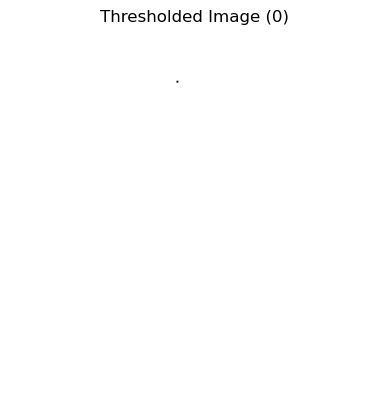

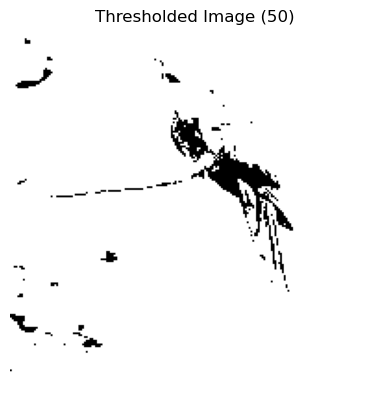

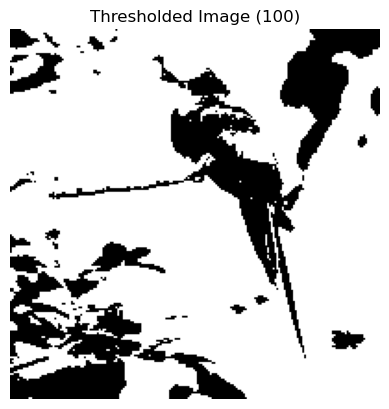

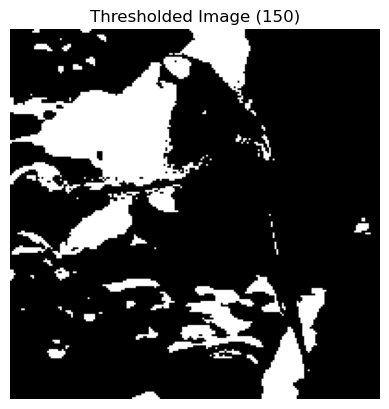

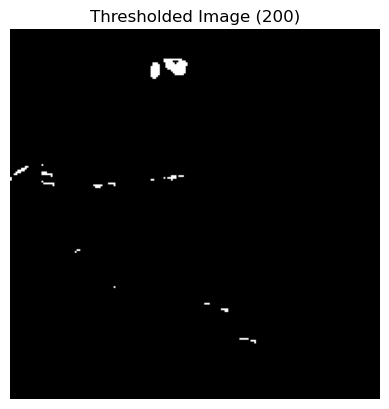

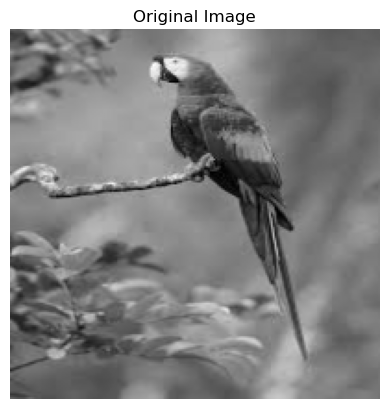

In [3]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('images/images.jpeg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (200, 200))

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Thresholded Image ({threshold_value})')
    plt.axis('off')
    plt.show()

# Display the original image
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

In [5]:
img = data.moon()

In [6]:
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

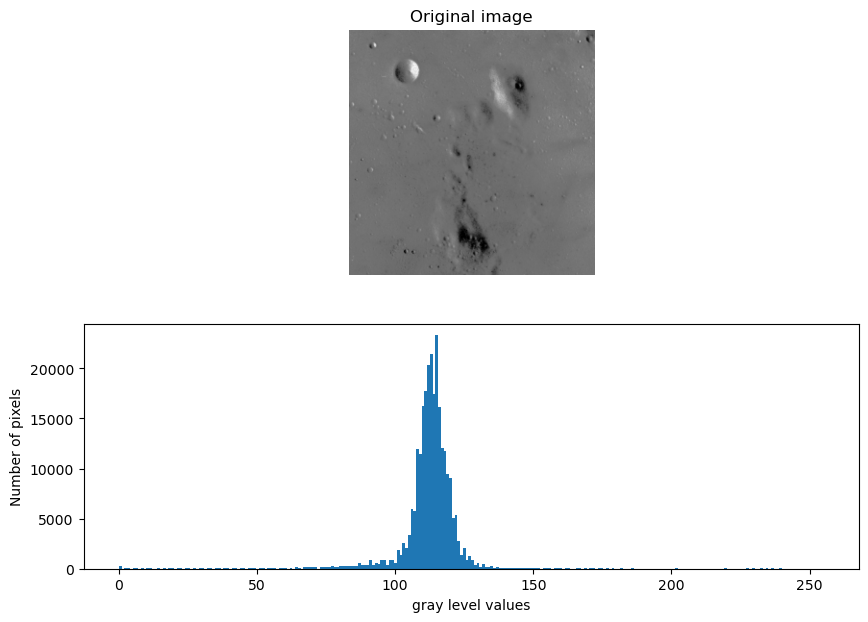

In [7]:
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 


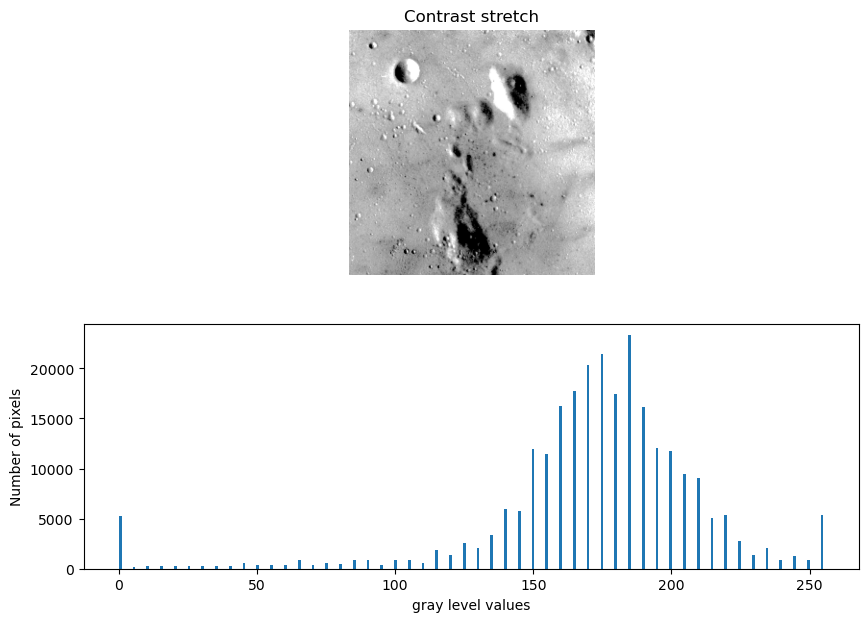

In [8]:
fig = plt.figure(figsize=(10, 7)) 	
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show()


dtype: uint8 | shape: (512, 512) | range: 0 - 255
3rd percentile = 87.0, 80th percentile = 118.0


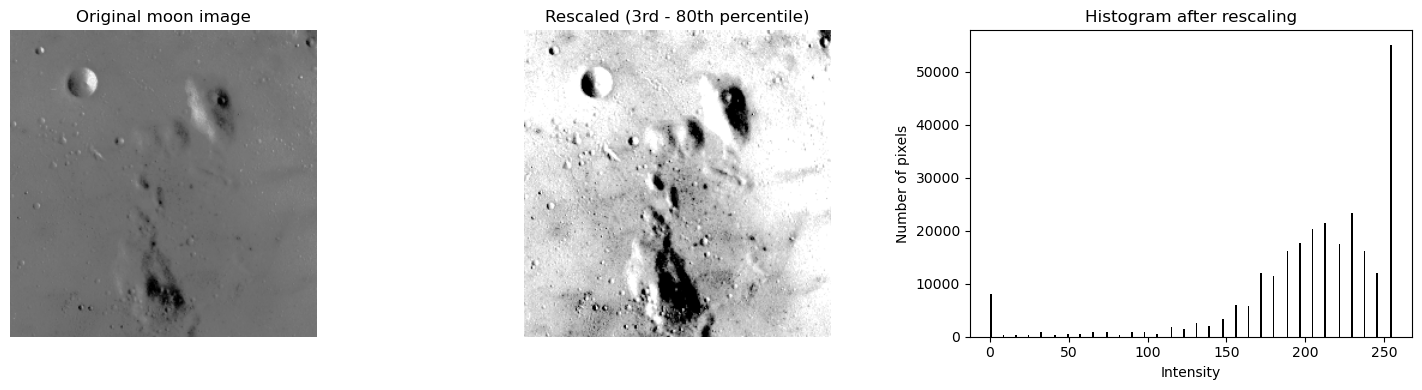

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

moon = data.moon()
print('dtype:', moon.dtype, '| shape:', moon.shape, '| range:', moon.min(), '-', moon.max())

# 3rd and 80th percentiles
p3, p80 = np.percentile(moon, [3, 80])
print(f'3rd percentile = {p3}, 80th percentile = {p80}')

# Rescale so intensities inside [p3, p80] map to the full [0, 255] range
moon_rescaled = exposure.rescale_intensity(moon, in_range=(p3, p80))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(moon, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original moon image')
axes[0].axis('off')

axes[1].imshow(moon_rescaled, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Rescaled (3rd - 80th percentile)')
axes[1].axis('off')

axes[2].hist(moon_rescaled.ravel(), bins=256, range=(0, 255), color='black')
axes[2].set_title('Histogram after rescaling')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()


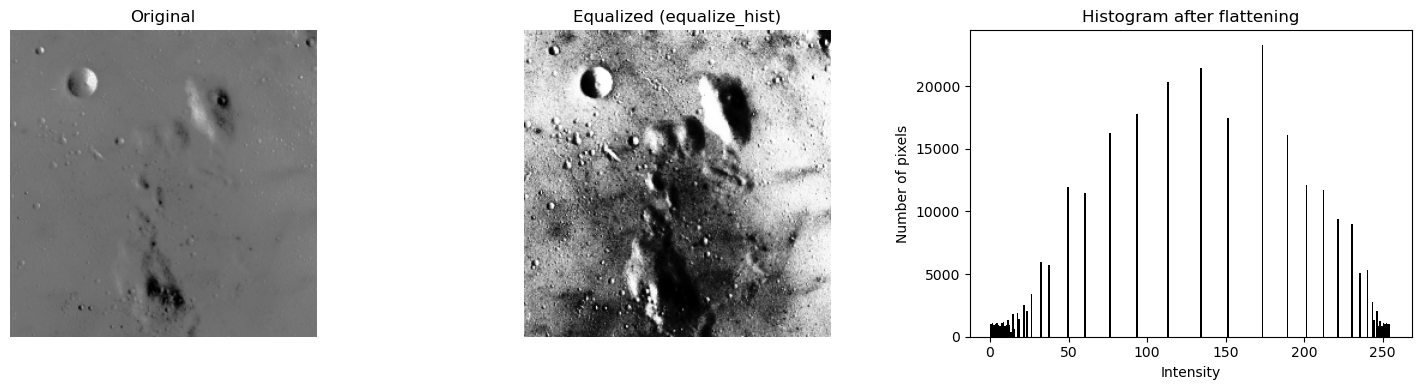

In [10]:
moon_eq = exposure.equalize_hist(moon)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(moon, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(moon_eq, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Equalized (equalize_hist)')
axes[1].axis('off')

# equalize_hist returns float in [0, 1], so use 256 bins over that range
axes[2].hist((moon_eq * 255).astype('uint8').ravel(), bins=256, range=(0, 256), color='black')
axes[2].set_title('Histogram after flattening')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()


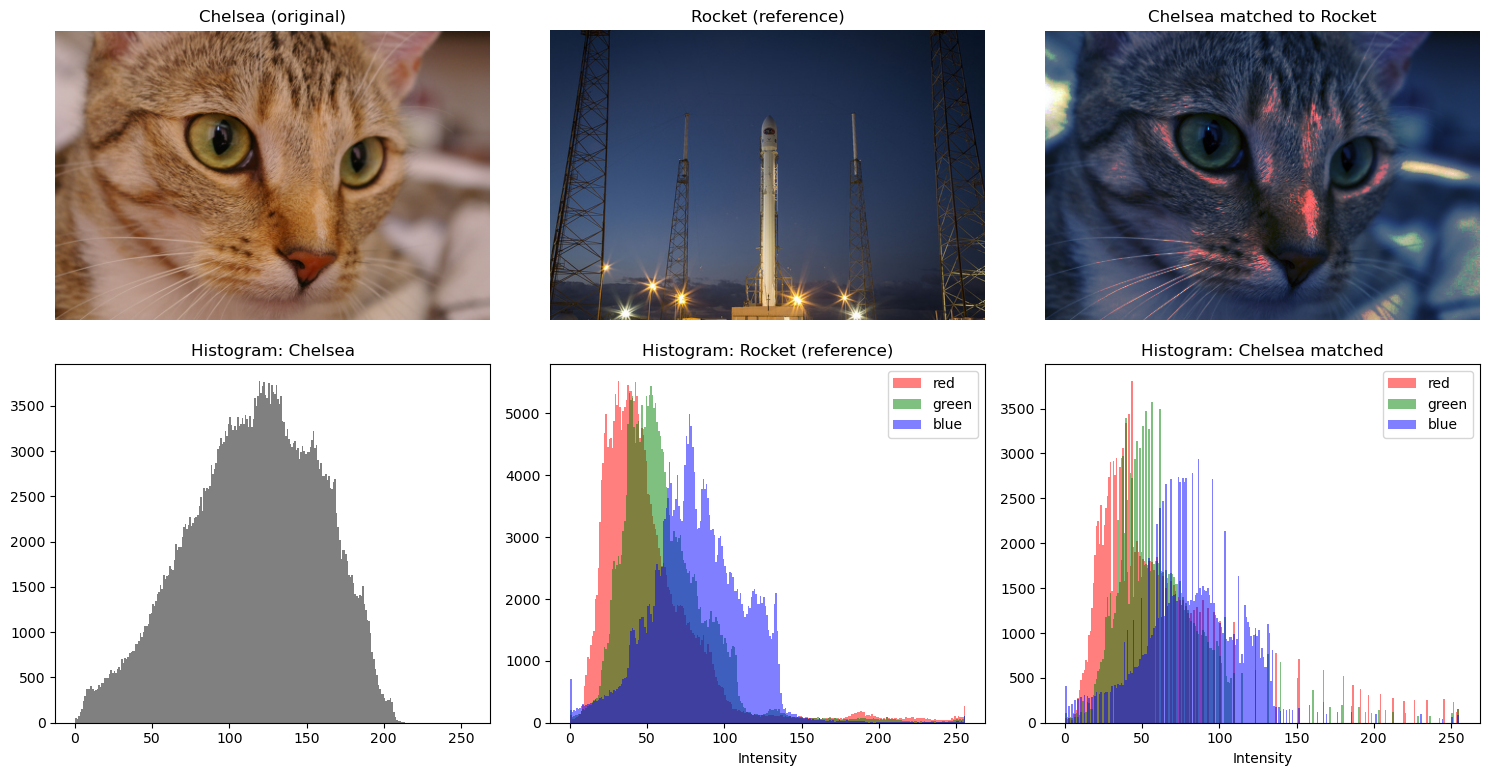

In [13]:
from skimage.exposure import match_histograms

rocket = data.rocket()      # reference image
chelsea = data.chelsea()    # image to be matched

# Match chelsea's histogram to the rocket's (channel_axis=-1 for RGB images)
chelsea_matched = match_histograms(chelsea, reference=rocket, channel_axis=-1)

def hist_rgb(img, ax, title):
    for chan, c in zip(range(3), ('red', 'green', 'blue')):
        ax.hist(img[..., chan].ravel(), bins=256, range=(0, 256),
                color=c, alpha=0.5, label=c)
    ax.set_title(title)
    ax.set_xlabel('Intensity')
    ax.legend()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(chelsea)
axes[0, 0].set_title('Chelsea (original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(rocket)
axes[0, 1].set_title('Rocket (reference)')
axes[0, 1].axis('off')

axes[0, 2].imshow(chelsea_matched)
axes[0, 2].set_title('Chelsea matched to Rocket')
axes[0, 2].axis('off')

axes[1, 0].hist(chelsea.ravel(), bins=256, range=(0, 256), color='gray')
axes[1, 0].set_title('Histogram: Chelsea')

hist_rgb(rocket, axes[1, 1], 'Histogram: Rocket (reference)')
hist_rgb(chelsea_matched, axes[1, 2], 'Histogram: Chelsea matched')

plt.tight_layout()
plt.show()
